# Santander

## Importar librerías

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [2]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/santander_data.csv")

# 2. eliminar las filas “raras” (las 2 primeras)
df = df[~df["Price"].isin(["Ticker", "Date"])].copy()

# 3. renombrar la primera columna porque en realidad es la fecha
df = df.rename(columns={"Price": "Date"})

# 4. convertir la fecha
df["Date"] = pd.to_datetime(df["Date"])

# 5. convertir el resto a numérico
for col in ["Close", "High", "Low", "Open", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# Para ser coherentes con lo anterior, creamos una columna PRICE fija:
df["Price"] = pd.to_numeric(df["Close"], errors="coerce")

# ordenar por fecha
df = df.sort_values("Date").reset_index(drop=True)

print(df.head())
print(df.dtypes)



        Date     Close      High       Low      Open   Volume     Price
0 2000-01-03  2.625067  2.661975  2.595079  2.652748  8797337  2.625067
1 2000-01-04  2.562785  2.606613  2.539718  2.592773  8811013  2.562785
2 2000-01-05  2.500502  2.546637  2.479742  2.514343  9333517  2.500502
3 2000-01-06  2.500502  2.500502  2.500502  2.500502        0  2.500502
4 2000-01-07  2.611227  2.618147  2.516651  2.518958  9603132  2.611227
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Price            float64
dtype: object


## PREPROCESAMIENTO

In [3]:
def preparar_datos_desde_df(df, col_target="Price", window_size=30):
    df = df.sort_values("Date").reset_index(drop=True)

    if col_target not in df.columns:
        raise ValueError(f"No encuentro la columna {col_target}. Tengo: {df.columns.tolist()}")

    valores = df[[col_target]].values.astype(float)

    scaler = MinMaxScaler(feature_range=(0, 1))
    valores_scaled = scaler.fit_transform(valores)

    X, y = [], []
    for i in range(window_size, len(valores_scaled)):
        X.append(valores_scaled[i-window_size:i, 0])
        y.append(valores_scaled[i, 0])

    X = np.array(X)
    y = np.array(y)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y, scaler, df

window_size = 30
X_santander, y_santander, scaler_santander, santander_df = preparar_datos_desde_df(df, col_target="Price", window_size=window_size)

print("X_santander:", X_santander.shape)
print("y_santander:", y_santander.shape)



X_santander: (6605, 30, 1)
y_santander: (6605,)


## Train y test temporal

In [4]:
# 80% train, 20% test (temporal, sin shuffle)
train_size = int(len(X_santander) * 0.8)
X_train, X_test = X_santander[:train_size], X_santander[train_size:]
y_train, y_test = y_santander[:train_size], y_santander[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (5284, 30, 1) (5284,)
Test : (1321, 30, 1) (1321,)


## Modelos

In [5]:
input_shape = (window_size, 1)

def build_rnn():
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


## Entrenamiento

In [41]:
# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 1000   # para RNN y GRU
EPOCHS_LSTM = 1000     # para LSTM
BATCH = 32

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, X_test, y_test):
    """
    Entrena un modelo (RNN, LSTM o GRU) con EarlyStopping y ModelCheckpoint.
    LSTM entrena más epochs (mínimo 500, máx 1000).
    """
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    model = build_fn()

    # Ruta completa donde guardar el modelo
    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_santander.h5")

    # Configurar callbacks
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=150 if nombre != "LSTM" else 400,  # más paciencia para LSTM
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    # Número de épocas dinámico
    epochs = EPOCHS_LSTM if nombre == "LSTM" else EPOCHS_DEFAULT

    # Entrenamiento
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR LOS TRES MODELOS
# ==============================

rnn_model,  hist_rnn  = entrenar_modelo("RNN",  build_rnn,  X_train, y_train, X_test, y_test)
lstm_model, hist_lstm = entrenar_modelo("LSTM", build_lstm, X_train, y_train, X_test, y_test)
gru_model,  hist_gru  = entrenar_modelo("GRU",  build_gru,  X_train, y_train, X_test, y_test)




🧠 Entrenando modelo RNN...

Epoch 1/1000


c:\Users\Usuario\OneDrive\Documentos\GitHub\Aprendizaje_Automatico\env11\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


158/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035
Epoch 1: val_loss improved from None to 0.00054, saving model to ..\modelos\mejor_rnn_santander.h5


166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0016 - val_loss: 5.3733e-04
Epoch 2/1000
146/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9760e-04
Epoch 2: val_loss improved from 0.00054 to 0.00027, saving model to ..\modelos\mejor_rnn_santander.h5


166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9796e-04 - val_loss: 2.7081e-04
Epoch 3/1000
152/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7767e-04
Epoch 3: val_loss improved from 0.00027 to 0.00016, saving model to ..\modelos\mejor_rnn_santander.h5


...

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3605e-04 - val_loss: 9.5939e-05
Epoch 27/1000
160/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3448e-04
Epoch 27: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3329e-04 - val_loss: 1.1901e-04
Epoch 28/1000
163/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2293e-04
Epoch 28: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3017e-04 - val_loss: 1.2121e-04
Epoch 29/1000
162/166 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3555e-04
Epoch 29: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2721e-04 - val_loss: 9.8483e-05
Epoch 30/1000
160/166 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3766e-04
Epoch 30: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2793e-04 - val_loss: 1.2795e-04
Epoch 31/1000
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2922e-04
Epoch 31: val_loss did 

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3386e-04 - val_loss: 9.5474e-05
Epoch 36/1000
162/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1871e-04
Epoch 36: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2124e-04 - val_loss: 1.6158e-04
Epoch 37/1000
156/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2551e-04
Epoch 37: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2511e-04 - val_loss: 1.1245e-04
Epoch 38/1000
157/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2405e-04
Epoch 38: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2930e-04 - val_loss: 1.1332e-04
Epoch 39/1000
160/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2070e-04
Epoch 39: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2581e-04 - val_loss: 1.1560e-04
Epoch 40/1000
157/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1516e-04
Epoch 40: val_loss did 

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2309e-04 - val_loss: 9.5281e-05
Epoch 108/1000
163/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1991e-04
Epoch 108: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2672e-04 - val_loss: 1.0722e-04
Epoch 109/1000
159/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2387e-04
Epoch 109: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2533e-04 - val_loss: 1.0271e-04
Epoch 110/1000
158/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2150e-04
Epoch 110: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2023e-04 - val_loss: 1.2557e-04
Epoch 111/1000
160/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2110e-04
Epoch 111: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2579e-04 - val_loss: 1.1701e-04
Epoch 112/1000
157/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2778e-04
Epoch 112: val

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2689e-04 - val_loss: 9.5028e-05
Epoch 119/1000
162/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3217e-04
Epoch 119: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2657e-04 - val_loss: 1.5288e-04
Epoch 120/1000
164/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3563e-04
Epoch 120: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2647e-04 - val_loss: 1.1184e-04
Epoch 121/1000
161/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2513e-04
Epoch 121: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2485e-04 - val_loss: 1.1806e-04
Epoch 122/1000
155/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2241e-04
Epoch 122: val_loss did not improve from 0.00010
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2517e-04 - val_loss: 1.3213e-04
Epoch 123/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2684e-04
Epoch 123: val

166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2389e-04 - val_loss: 9.4580e-05
Epoch 138/1000
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2974e-04
Epoch 138: val_loss did not improve from 0.00009
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2583e-04 - val_loss: 1.0820e-04
Epoch 139/1000
165/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2962e-04
Epoch 139: val_loss did not improve from 0.00009
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2387e-04 - val_loss: 1.3677e-04
Epoch 140/1000
161/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2342e-04
Epoch 140: val_loss did not improve from 0.00009
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2414e-04 - val_loss: 1.3174e-04
Epoch 141/1000
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1736e-04
Epoch 141: val_loss did not improve from 0.00009
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.2307e-04 - val_loss: 9.8411e-05
Epoch 142/1000
162/166 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1706e-04
Epoch 142: val

In [42]:
# todas con la misma forma de entrada
input_shape = (window_size, 1)

def build_rnn():
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_lstm():
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

## Predicciones

In [43]:
# predicciones (en escala 0-1)
y_pred_rnn  = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru  = gru_model.predict(X_test)

# desescalar
y_test_real = scaler_santander.inverse_transform(y_test.reshape(-1, 1))
pred_rnn_real  = scaler_santander.inverse_transform(y_pred_rnn)
pred_lstm_real = scaler_santander.inverse_transform(y_pred_lstm)
pred_gru_real  = scaler_santander.inverse_transform(y_pred_gru)


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## Métricas

In [44]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_rnn, rmse_rnn   = evaluar(y_test_real, pred_rnn_real)
mae_lstm, rmse_lstm = evaluar(y_test_real, pred_lstm_real)
mae_gru, rmse_gru   = evaluar(y_test_real, pred_gru_real)

print("RNN  -> MAE:", mae_rnn,  "RMSE:", rmse_rnn)
print("LSTM -> MAE:", mae_lstm, "RMSE:", rmse_lstm)
print("GRU  -> MAE:", mae_gru,  "RMSE:", rmse_gru)


RNN  -> MAE: 0.05192796638930592 RMSE: 0.07420823899706315
LSTM -> MAE: 0.051477759286907926 RMSE: 0.07401793245606013
GRU  -> MAE: 0.05191351860242752 RMSE: 0.07421431623515323


# Graficar

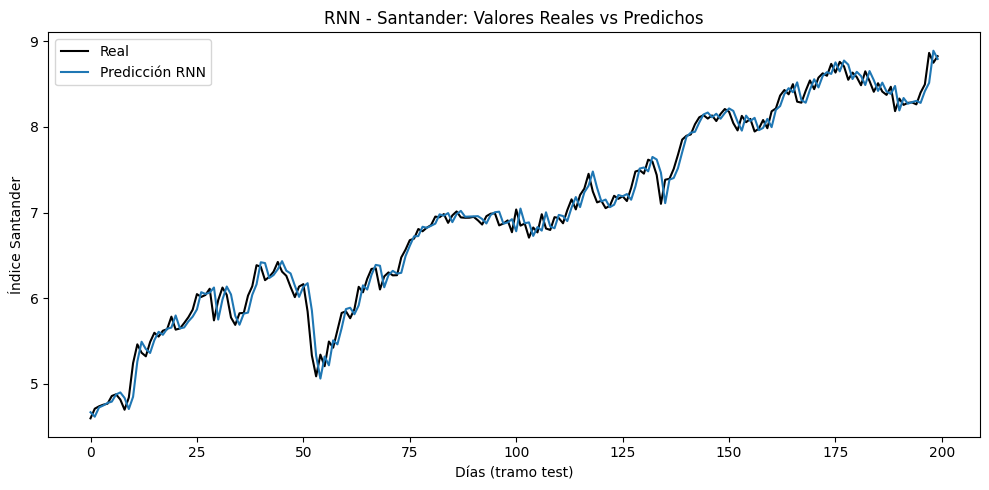

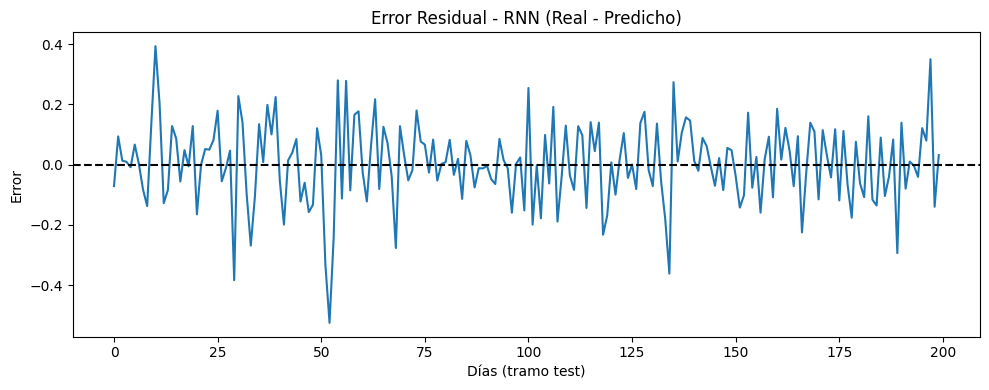

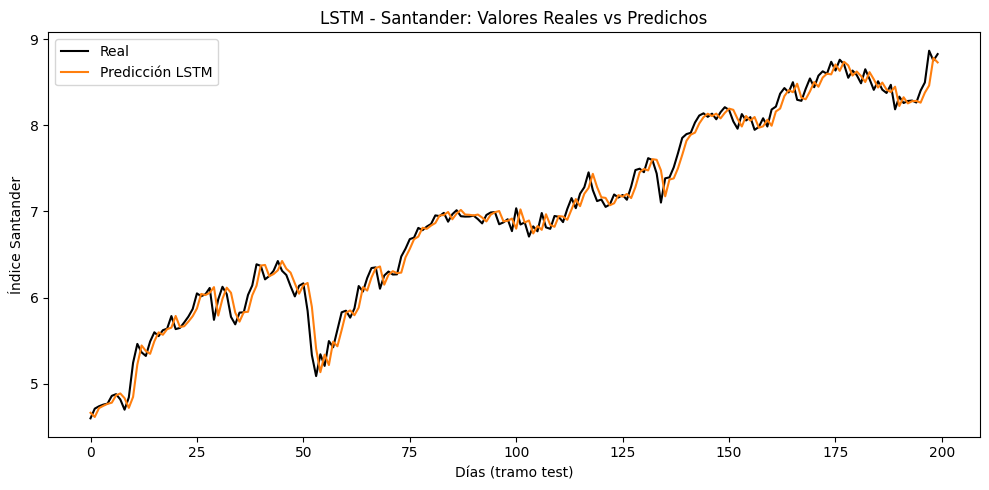

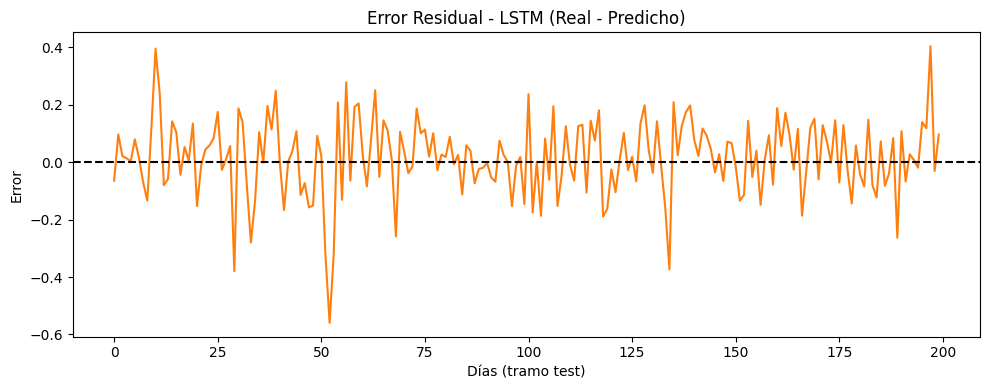

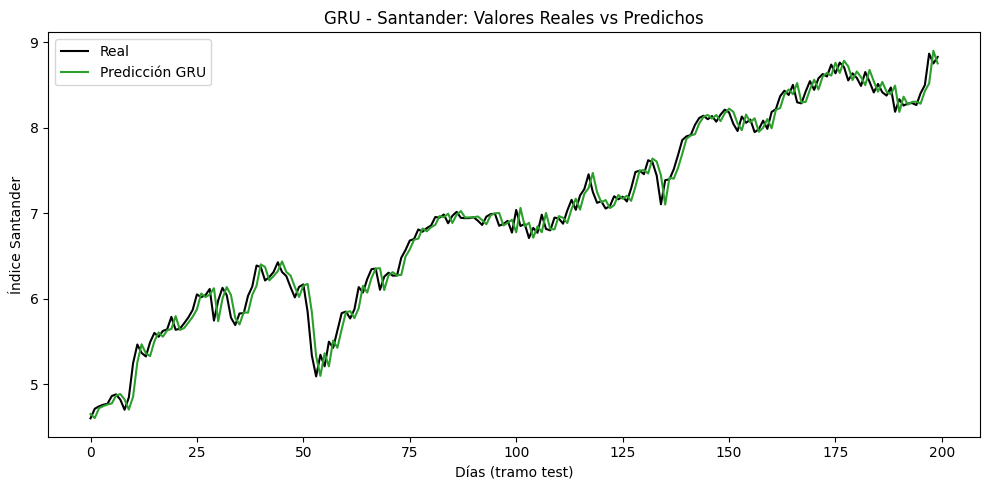

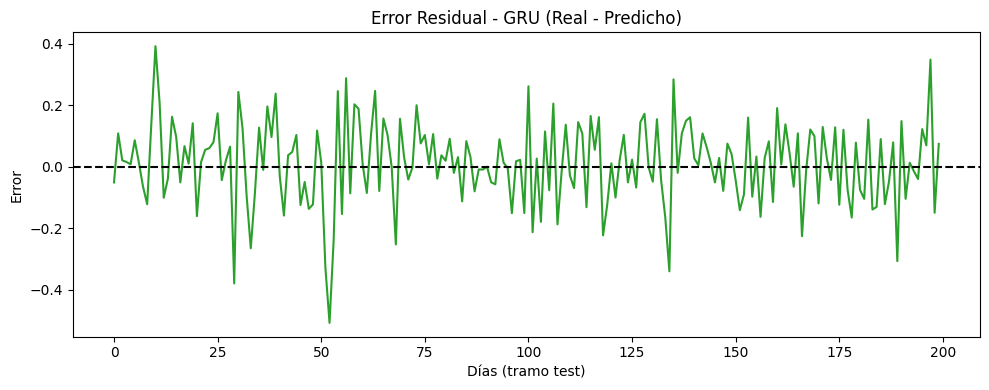

In [45]:
# --- Tramo a mostrar (últimos 200 días del test, por ejemplo) ---
n_mostrar = 200
y_real_plot = y_test_real[-n_mostrar:]
pred_rnn_plot  = pred_rnn_real[-n_mostrar:]
pred_lstm_plot = pred_lstm_real[-n_mostrar:]
pred_gru_plot  = pred_gru_real[-n_mostrar:]

# ===============================
# 1️⃣ RNN
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_rnn_plot, label="Predicción RNN", color="tab:blue")
plt.title("RNN - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error RNN ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_rnn_plot, color="tab:blue")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - RNN (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 2️⃣ LSTM
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_plot, label="Predicción LSTM", color="tab:orange")
plt.title("LSTM - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error LSTM ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_plot, color="tab:orange")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

# ===============================
# 3️⃣ GRU
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_gru_plot, label="Predicción GRU", color="tab:green")
plt.title("GRU - Santander: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice Santander")
plt.legend()
plt.tight_layout()
plt.show()

# --- Error GRU ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_gru_plot, color="tab:green")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - GRU (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


In [46]:
def predecir_siguiente(model, df_original, scaler, col_target="Price", window_size=30):
    # usamos el df limpio que tenías: santander_df
    ultimos = df_original[[col_target]].values.astype(float)[-window_size:]
    ultimos_scaled = scaler.transform(ultimos)
    X_input = ultimos_scaled.reshape((1, window_size, 1))
    pred_scaled = model.predict(X_input)
    pred = scaler.inverse_transform(pred_scaled)
    return pred[0,0]

pred_manana_lstm = predecir_siguiente(lstm_model, santander_df, scaler_santander, col_target="Price", window_size=window_size)
print("Predicción Santander próximo día (LSTM):", pred_manana_lstm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicción Santander próximo día (LSTM): 8.815355


## Predecir dias futuros

In [47]:
def predecir_n_dias(model, df_original, scaler, col_target="Price", window_size=30, n_dias=5):
    # 1. cogemos los últimos window_size valores reales
    serie = df_original[[col_target]].values.astype(float)
    ultimos = serie[-window_size:]  # shape (30, 1)

    # los pasamos a escala
    ultimos_scaled = scaler.transform(ultimos)

    preds_desescaladas = []

    # trabajamos en una copia que iremos ampliando
    ventana_actual = ultimos_scaled.copy()  # shape (30,1)

    for _ in range(n_dias):
        # (1, pasos, 1)
        X_input = ventana_actual.reshape((1, window_size, 1))
        pred_scaled = model.predict(X_input, verbose=0)
        # desescalar
        pred_real = scaler.inverse_transform(pred_scaled)[0, 0]
        preds_desescaladas.append(pred_real)

        # ahora actualizamos la ventana: quitamos el 1º y metemos la predicción al final
        nuevo_valor_scaled = pred_scaled  # shape (1,1)
        ventana_actual = np.vstack([ventana_actual[1:], nuevo_valor_scaled])

    return preds_desescaladas

In [48]:
# última fecha real
ultima_fecha = santander_df["Date"].max()

# generamos 5 fechas a partir de la última
fechas_futuras = pd.date_range(start=ultima_fecha + pd.Timedelta(days=1),
                               periods=5, freq="B")  # "B" para días hábiles

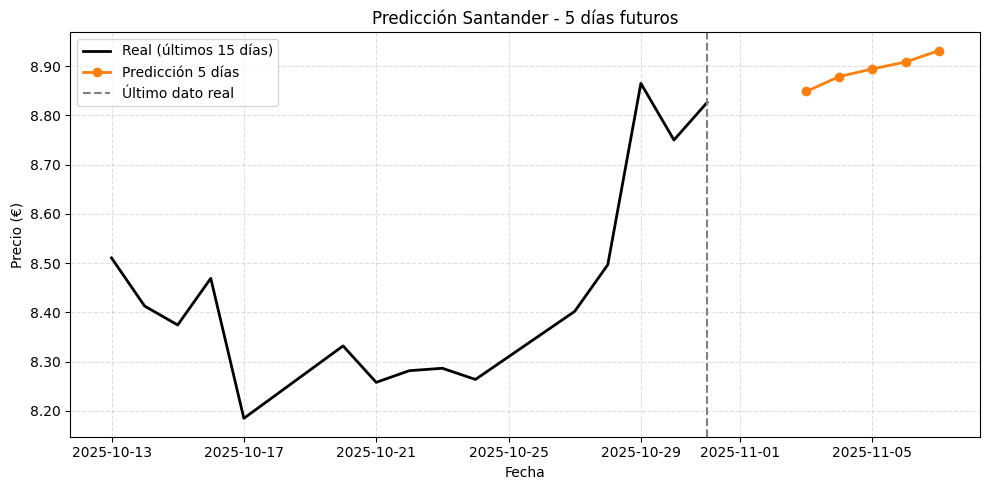

In [ ]:
# 1) obtenemos las 5 predicciones
preds_5 = predecir_n_dias(
    rnn_model,
    santander_df,
    scaler_santander,
    col_target="Price",
    window_size=window_size,
    n_dias=5
)

# 2) hacemos un DataFrame de futuro
df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_Price": preds_5
})

# 3) últimos 15 días reales
historico_plot = santander_df[["Date", "Price"]].tail(15).copy()


plt.figure(figsize=(10,5))

# histórico
plt.plot(historico_plot["Date"], historico_plot["Price"],
         label="Real (últimos 15 días)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_Price"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - 5 días futuros")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")
plt.legend()

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

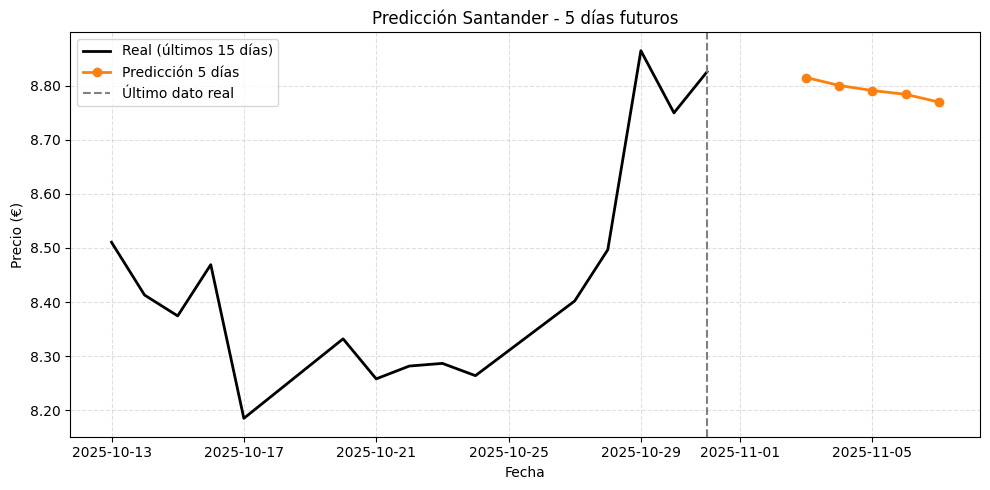

In [ ]:
# 1) obtenemos las 5 predicciones
preds_5 = predecir_n_dias(
    lstm_model,
    santander_df,
    scaler_santander,
    col_target="Price",
    window_size=window_size,
    n_dias=5
)

# 2) hacemos un DataFrame de futuro
df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_Price": preds_5
})

# 3) últimos 15 días reales
historico_plot = santander_df[["Date", "Price"]].tail(15).copy()


plt.figure(figsize=(10,5))

# histórico
plt.plot(historico_plot["Date"], historico_plot["Price"],
         label="Real (últimos 15 días)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_Price"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - 5 días futuros")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")
plt.legend()

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


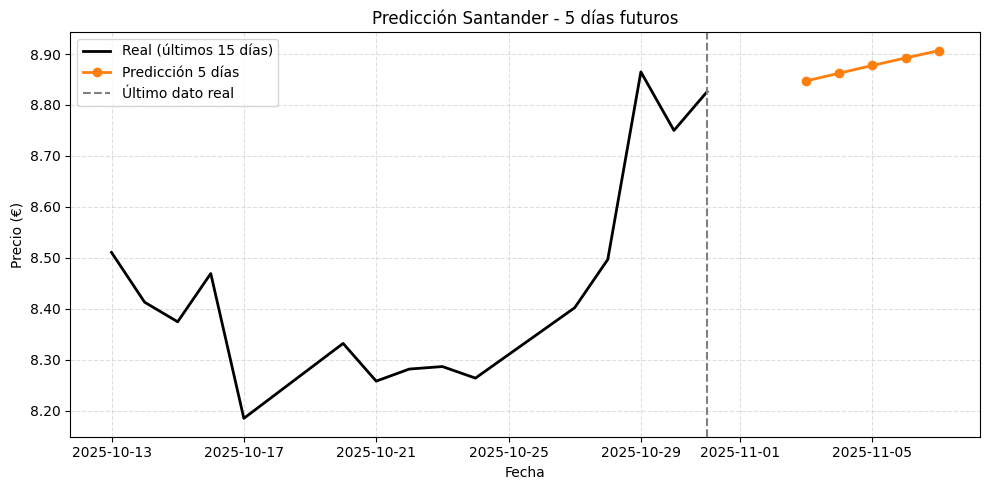

In [ ]:
# 1) obtenemos las 5 predicciones
preds_5 = predecir_n_dias(
    gru_model,
    santander_df,
    scaler_santander,
    col_target="Price",
    window_size=window_size,
    n_dias=5
)

# 2) hacemos un DataFrame de futuro
df_futuro = pd.DataFrame({
    "Date": fechas_futuras,
    "Predicted_Price": preds_5
})

# 3) últimos 15 días reales
historico_plot = santander_df[["Date", "Price"]].tail(15).copy()


plt.figure(figsize=(10,5))

# histórico
plt.plot(historico_plot["Date"], historico_plot["Price"],
         label="Real (últimos 15 días)", color="black", linewidth=2)

# futuro
plt.plot(df_futuro["Date"], df_futuro["Predicted_Price"],
         label="Predicción 5 días", color="tab:orange", marker="o", linewidth=2)

# línea de corte
plt.axvline(historico_plot["Date"].max(), color="gray", linestyle="--", label="Último dato real")

plt.title("Predicción Santander - 5 días futuros")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")
plt.legend()

# 2 decimales en eje Y
plt.gca().yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()